## What you will learn
-  How to  manipulate data sets and get data in a useful form. 
- How to build, train and validate a ML model


Remember - machine learning is about writing programs that learn from data in order to make decisions based on future unseen data. 


### Example activity
Suppose that we want to use the linear regression algorithm to predict students final grade based on a series of attributes. Clearly, we need hisotical data, which may not always be in the right shape. 
For this tutorial, we will use a fairy clean dataset to gain knowledge about ML workflow.

The dataset is contained in a CSV file - Student-Mat.csv 

# Linear Regression
- predicting continuous values
- Keys terms
    - features
    - samples
    - training 
    - testing
    - predicting
    - performance


## About the dataset
The data comprises students achievement in secondary education of two Portuguese schools. The features/attributes include student grades, demographic, social and school related features).  Initially, data was collected using school reports and questionnaires. The dataset we concerned with regards Maths subject.
The target attribute G3 has a strong correlation with attributes G2 and G1. This occurs because G3 is the final year grade (issued at the 3rd period), while G1 and G2 correspond to the 1st and 2nd period grades. It is more difficult to predict G3 without G2 and G1.

<b> In this tutorial, we will work with the Students-mat dataset</b>

## Let's import packages that we will need
- Then we load the data
- We shall then inspect the data 
- Subsequently, we make mention of key terms used to describe data in Machine Learning

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn import linear_model
from sklearn.utils import shuffle
import seaborn as sns
# import warnings
# warnings.filterwarnings("ignore")

## Now, we load the dataset
We have the dataset on disk as a CSV file, now  load it in using the pandas module.

In [3]:
dataframe = pd.read_csv("students-mat.csv", sep=";")

## Do a quick view of the first 5 records

In [6]:
dataframe.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
dataframe.tail(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
385,MS,F,18,R,GT3,T,2,2,at_home,other,...,5,3,3,1,3,4,2,10,9,10
386,MS,F,18,R,GT3,T,4,4,teacher,at_home,...,4,4,3,2,2,5,7,6,5,6
387,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,0,7,5,0
388,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,0,7,9,8
389,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,0,6,5,0
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


## check the structure of the dataframe

In [4]:
#dataframe.info()
## how many columns? how many entries/records?

dataframe.shape[0]

395

## Quick thoughts
- The number of records is usually called <b>Sample Size</b>. Hence the sample size here is 395 student records.
- The columns, are also called <b>attributes</b>. A more common term is <b>features</b>. Each record has 33 features in this dataset

## Selecting features to work with
33 features is way too much to work with. Some of them are not useful for our task. We can trim the dataset to work with the features we feel are relevant to our task

In [5]:
## another (longer) way of slicing...
#dataframe.info()
#cols = ["G1", "G2", "G3", "studytime", "failures", "absences"]
df2 = dataframe[["G1", "G2", "G3", "studytime", "failures", "absences"]]

df2.head()

#type(df2)

,G1,G2,G3,studytime,failures,absences
0,5,6,6,2,0,6
1,5,5,6,2,0,4
2,7,8,10,2,3,10
3,15,14,15,3,0,2
4,6,10,10,2,0,4


In [6]:
# even better
df2 = dataframe[["G1", "G2", "G3", "studytime", "failures", "absences"]]

In [7]:
## check the structure again
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   G1         395 non-null    int64
 1   G2         395 non-null    int64
 2   G3         395 non-null    int64
 3   studytime  395 non-null    int64
 4   failures   395 non-null    int64
 5   absences   395 non-null    int64
dtypes: int64(6)
memory usage: 18.6 KB


In [15]:
## read first records again
df2.head()

,G1,G2,G3,studytime,failures,absences
0,5,6,6,2,0,6
1,5,5,6,2,0,4
2,7,8,10,2,3,10
3,15,14,15,3,0,2
4,6,10,10,2,0,4


## Preparing our data for a machine learning model
<b> Separate data into the feature we want to predict, and the features we want to use for the prediction. </b>
Some common terms (again): <br>
- <b>label</b> or <b>target</b> - it is the attribute or value we want to predict. In this case `G3`. It is also called a <b>dependent</b> variable.
- <b> features</b> - the attributes used to predict the label. They are also called <b>independent</b> variables.

### Reflection:
See how useful `pandas` is. <br>
See how key `NumPy` is.

These two modules are indespensable in Python's Data Science Ecosystem.



In [11]:
predict = "G3"

X = np.array(df2.drop([predict], axis =1)) # drop column G3 
y = np.array(df2[predict]) # Labels - create a target vector using G3

In [12]:
X.shape # why is this 395 by 5?
#X.ndim # what does this show?

(395, 5)

In [13]:
y.shape # why is the 395,?
#y.ndim

(395,)

## Training and Testing data
Now we have two arrays - that of labels and features.
We need a further step. We need to decide how much of the labels and features we are using for training, and how much for testing. In other words, we need to decide:
- Split features  and labels to a certain % for training
- Retain a certain % of features for testing
- Retain a certain % of labels for validation/testing

Let's go for it.

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)

# TensorFlow, Keras
# what is X again?
# what is y?
# the hyperparameter test_size = 0.1 means keep 10% of the data for testing
# Quick calculation - how many records are used for training and testing?

# What is x_train, x_test, y_train, y_test?

In [33]:
type(x_test)

numpy.ndarray

## Implementing the Linear Regression Model
We proceed as follows:
1. Import the Linear Regression class from Python's sklearn
2. Instatiate a model 
3. Fit (train) the model with the training dataset
- x_train and y_train
4. ...then...Test the model 
- with x_test and compare with y_test

## A small detour
### How does  Linear Regression work?
It really is about finding the best line of fit for your data. Given a set of data points the algorithm will create a best line of fit through those data points.

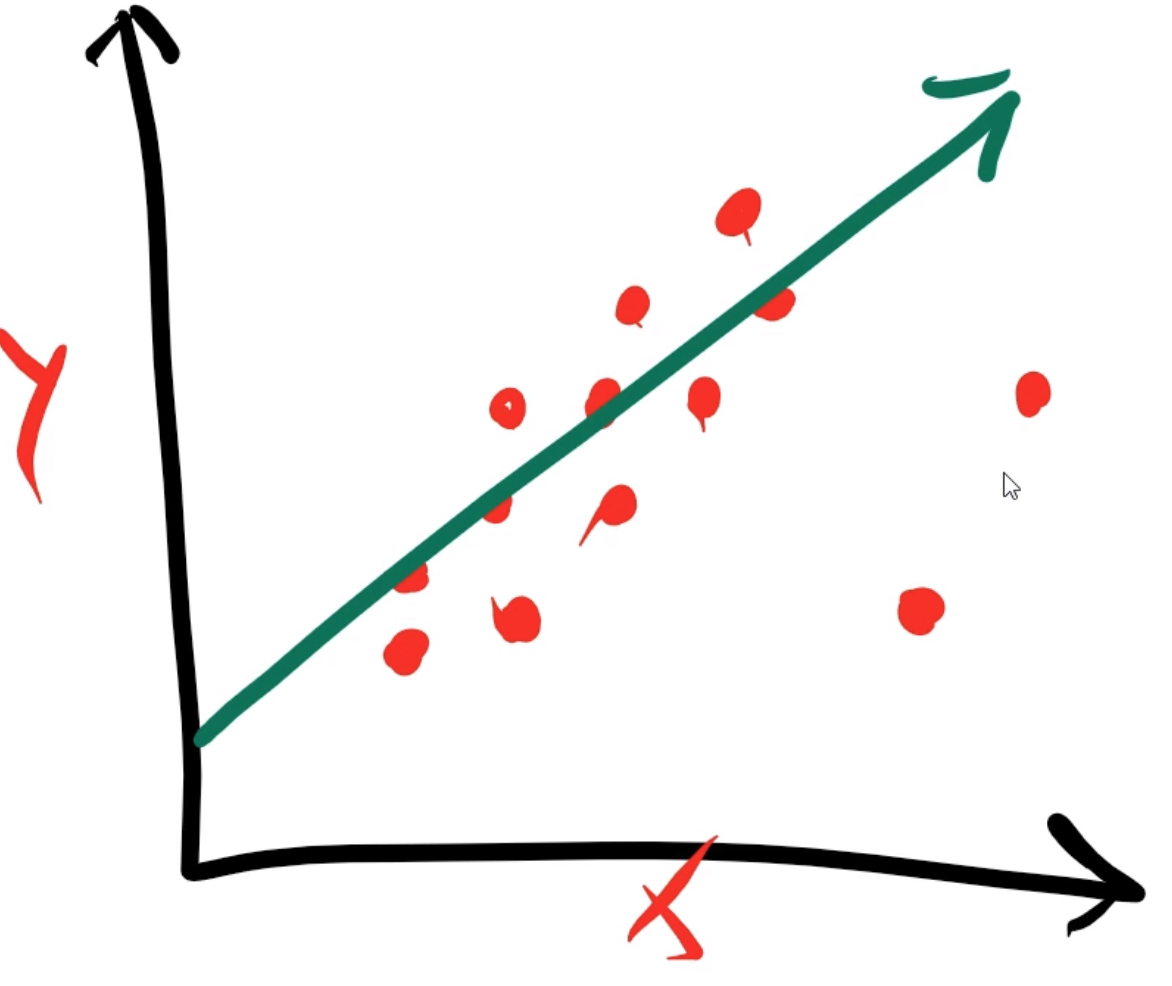

## Key equation
The line of fit is defined by the equation y = m*x + b.<br>
<b>m</b> - the slope. This indicates how much the `y` value increases for each `x` value.

<b>b</b> -  the `y` intercept. This is where the line crosses the `y` axis.

We can determine the slope of the line by picking two points on the line (p1 and p2) and using the following equation: <b>m = (y2 - y1) / (x2 - x1) </b>

Once our algorithm has generated this line it will use it to predict values based on new data.

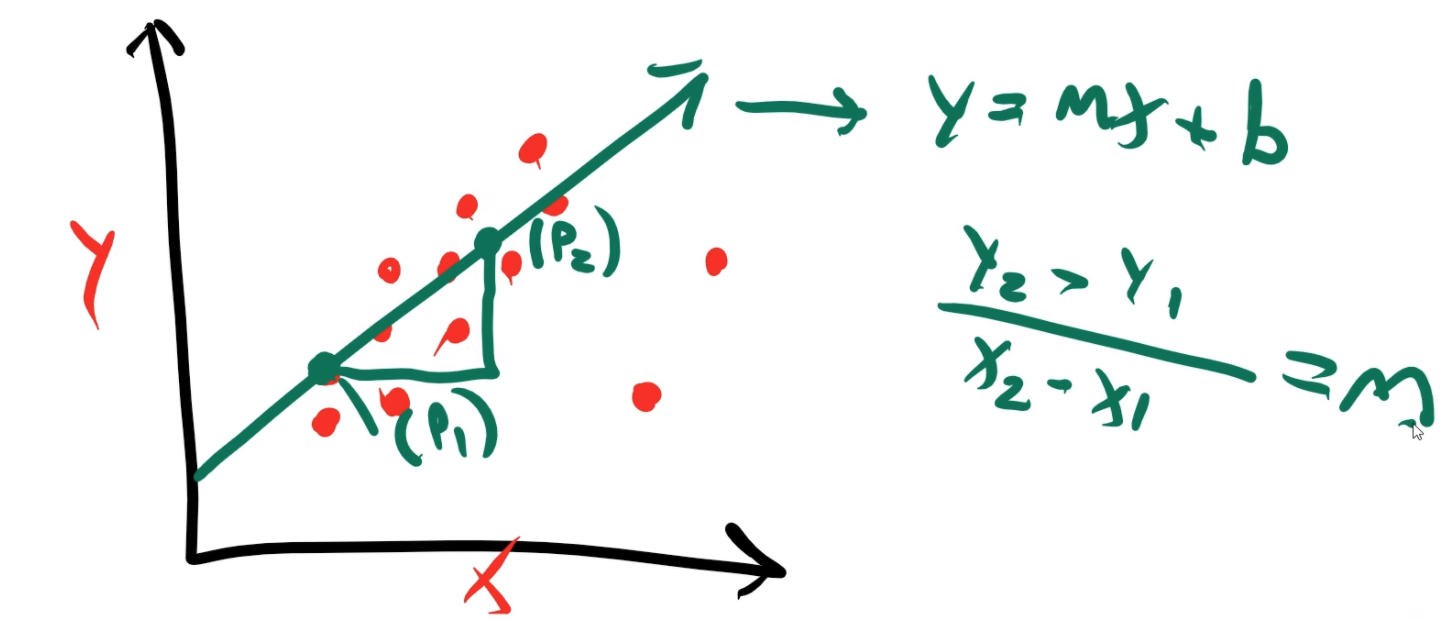

## Create and implement the algorithm


In [15]:
# create a model instance
linear = linear_model.LinearRegression()
# Object Orientation 

### Train the model using the arrays we created
 

In [16]:
linear.fit(x_train, y_train) # what is this doing?


LinearRegression()

In [17]:
linear.coef_

array([ 0.18339733,  0.9475475 , -0.18438484, -0.31680562,  0.03603116])

In [22]:
#df2.head()

## Predicting grades for students

In [23]:
# for i in range(len(predictions)): 
#     print(predictions[i], x_test[i],y_test[i])
    

# for i in range(len(predictions)): 
#     print(predictions[i], x_test.iloc[i],y_test.iloc[i])

In [15]:
print(x_test[0], y_test[0])

[7 9 3 0 0] 8


In [18]:
predictions = linear.predict(x_test) # Get a list of all predictions

In [19]:
# we now print what the model has predicted and what the actual values are (y_test)
for x in range(len(predictions)):
    print(predictions[x], x_test[x], y_test[x])

8.151161884141661 [10  9  4  0  0] 0
13.839663191093102 [13 14  3  0  6] 14
7.217293274644517 [8 8 1 1 4] 8
15.957428198122791 [15 16  3  0  2] 18
11.730356234111582 [11 12  1  0  0] 10
12.676916223505598 [12 13  2  0  0] 13
11.109343205462027 [13 11  2  0  4] 11
15.121215701803038 [16 15  3  0  0] 15
7.389974245456255 [8 8 1 0 0] 11
14.247705548996802 [14 14  1  0  2] 14
9.31489636225245 [10 10  4  0  6] 11
6.143837532851192 [7 8 2 3 2] 9
12.932375879232135 [13 13  2  0  2] 13
17.85249799090423 [17 17  2  0 13] 17
11.729368723588298 [12 12  2  0  0] 11
12.86031355316764 [13 13  2  0  0] 12
9.243821546711239 [ 9 10  3  0  4] 10
10.742548546137947 [11 11  2  0  4] 11
14.756396063525525 [12 15  1  0  0] 15
7.969739575526191 [7 9 2 0 0] 8
18.035920527619435 [16 18  3  0  2] 18
12.209502919434273 [10 13  2  1  6] 13
12.340936191666394 [11 13  4  0  6] 14
3.54692584049881 [6 5 1 2 0] 0
5.704980547462615 [5 8 2 3 0] 7
-0.007995934743394661 [10  0  2  0  0] 0
13.950998194690646 [14 14  3  0  

## How accurate is our model?
We use an inbuilt function to check how accurate our model is

In [20]:
acc = linear.score(x_test, y_test) 
acc

0.7589869549353216

## Coefficients

## Saving our trained/tested model
We could train various models and decide on the one to keep and use.
We can then use the module pickle to save the model, which we retrieve and use when we want to make predictions. 

We save our model by writing it to a new a new file using <b>pickle.dump() </b>.

In [21]:
## save the model

import pickle 
f = open("model", "wb")
pickle.dump(linear, f)

## Model retrieval
We now assume we want to load our saved model  so we can use it. 
At this point, you can remove the code that creates and trains our model as we are simply loading a ready one from the pickle file.

## Training multiple models

Models vary in accuracy. This is because when we split the data into training and testing data it is divided differently each time. Since our model trains very quickly it may be worth training multiple models and saving the best one. 
Let's do it here:

In [22]:
# TRAIN MODEL MULTIPLE TIMES FOR BEST SCORE
best = 0
for i in range(20):
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
    linear = linear_model.LinearRegression()
    linear.fit(x_train, y_train)
    acc = linear.score(x_test, y_test)
    print("Accuracy: " + str(acc))
  # If the current model has a better score than one we've already trained then save it
    if acc > best:
        best = acc
        with open("studentgrades.pickle", "wb") as f:
            pickle.dump(linear, f)

Accuracy: 0.7603730577617185
Accuracy: 0.7652809127556071
Accuracy: 0.9180835694147776
Accuracy: 0.7649848665823002
Accuracy: 0.8955287918030396
Accuracy: 0.5377003818234841
Accuracy: 0.7956464339840658
Accuracy: 0.7721029752938573
Accuracy: 0.8078216884475413
Accuracy: 0.9078494305661168
Accuracy: 0.8884250100523683
Accuracy: 0.8707003970497537
Accuracy: 0.6093408203979386
Accuracy: 0.7945605764312075
Accuracy: 0.896700806288533
Accuracy: 0.9146884767241739
Accuracy: 0.8657211642351595
Accuracy: 0.7391561613817184
Accuracy: 0.6973162785079541
Accuracy: 0.7995984074515553


Now you can load the best model

In [16]:
pickle_in = open("studentgrades.pickle", "rb")
linear = pickle.load(pickle_in)

In [23]:
pre = linear.predict(x_test)

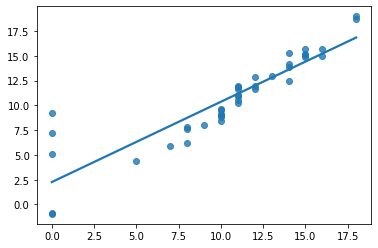

In [24]:
sns.regplot(x = y_test, y=pre, ci = None);


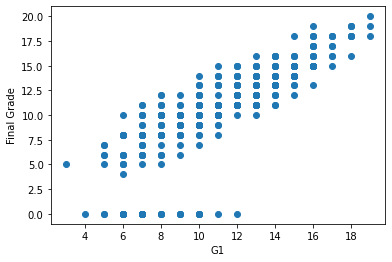

In [61]:
# Drawing and plotting model
import matplotlib.pyplot as plt 
plot = "G1" # Change this to G1, G2, studytime or absences to see other graphs
plt.scatter(dataframe[plot], dataframe["G3"]) 
plt.xlabel(plot)
plt.ylabel("Final Grade")
plt.show()

## Summary
The key take-aways are:
- We have used two key modules to get data ready for a ML algorithm
- We have clarified some key terminologies used describing ML activities and data
- We have worked with a substantial dataset to train a ML model
- We managed to persist a model to a file and retrieve it and use it
- We did some plots

# Reflection
Can we come up with some steps that we could go through to perform a similar model training task?

What would we have to do? 

What do we need?